In [1]:
import pandas as pd
from datetime import timedelta


df_prices = pd.read_csv('E:\Signal Backtesting\Input\Price_2024.csv')
# Re-load the signal data without setting the index
df_signals = pd.read_csv('E:\Signal Backtesting\Input\Signature_AI_Results_Final.csv')

# Convert 'Datetime' column to datetime
df_signals['Datetime'] = pd.to_datetime(df_signals['Datetime'])
df_prices['Datetime'] = pd.to_datetime(df_prices['Datetime'])

# Set 'Datetime' as index for price dataframe for easy slicing
df_prices.set_index('Datetime', inplace=True)

# Sort the price dataframe by datetime in ascending order
df_prices.sort_index(inplace=True)


In [7]:
# Define the function to calculate percentage change
def calculate_percentage_change(signal, signal_datetime, df_prices):
    # Find the nearest previous datetime if the exact one doesn't exist
    if signal_datetime not in df_prices.index:
        signal_datetime = df_prices.index[df_prices.index.get_loc(signal_datetime, method='pad')]
    
    # Get the price at signal datetime
    signal_price = df_prices.loc[signal_datetime, 'Open']
    
    # Define the time window
    end_datetime = signal_datetime + timedelta(hours=2)
    
    # Slice the price dataframe for the time window
    price_window = df_prices.loc[signal_datetime:end_datetime]
    
    # Calculate lowest/highest price in the window based on signal
    if signal == 2:  # Buy signal, find lowest price
        target_price = price_window['Low'].min()
    elif signal == -2:  # Sell signal, find highest price
        target_price = price_window['High'].max()
    
    # Calculate percentage change
    percentage_change = ((target_price - signal_price) / signal_price) * 100
    
    return signal_price, target_price, percentage_change

# Initialize a list to store the results
results = []

# Loop through each signal
for index, row in df_signals.iterrows():
    signal = row['Signal']
    signal_datetime = row['Datetime']
    signal_price, target_price, percentage_change = calculate_percentage_change(signal, signal_datetime, df_prices)
    results.append({
        "Datetime": signal_datetime,
        "Signal": signal,
        "Price at Signal": signal_price,
        "Target Price": target_price,
        "Percentage Change": percentage_change
    })

# Create a new dataframe with the results
df_results = pd.DataFrame(results)

df_results

,Datetime,Signal,Price at Signal,Target Price,Percentage Change
0,2024-01-01 00:00:00,-2,42314.0,42832.0,1.224181
1,2024-01-01 16:00:00,2,42818.0,42693.1,-0.291700
2,2024-01-02 00:00:00,-2,44230.3,45485.7,2.838326
3,2024-01-02 22:00:00,2,45154.9,44818.1,-0.745877
4,2024-01-03 16:00:00,2,43014.0,42595.0,-0.974101
...,...,...,...,...,...
214,2024-06-27 08:00:00,-2,60786.4,61347.8,0.923562
215,2024-06-28 08:00:00,2,61318.0,61181.9,-0.221958
216,2024-06-28 16:00:00,-2,61039.9,61106.0,0.108290
217,2024-06-29 03:00:00,2,60765.3,60706.5,-0.096766


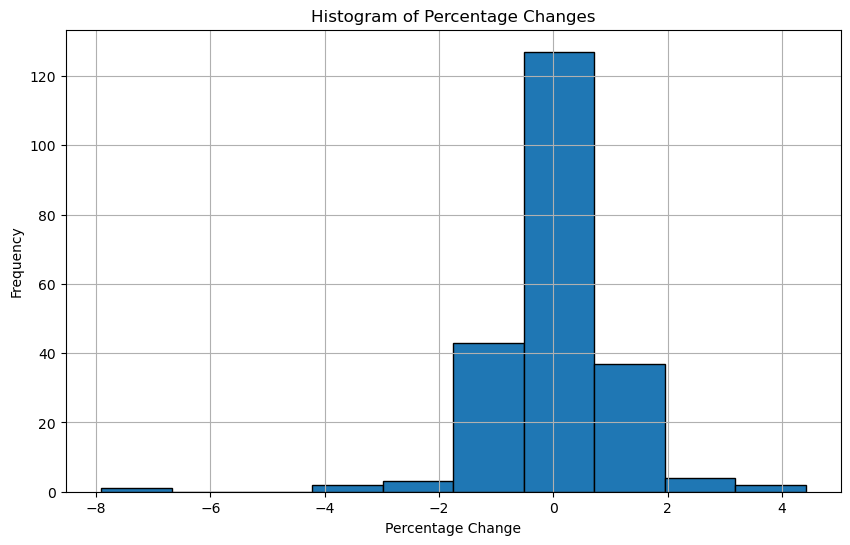

In [8]:
import matplotlib.pyplot as plt

# Plot the histogram of percentage changes
plt.figure(figsize=(10, 6))
plt.hist(df_results['Percentage Change'], bins=10, edgecolor='black')
plt.title('Histogram of Percentage Changes')
plt.xlabel('Percentage Change')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
